In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from models import SimpleCNN, trainset, testset, trainloader, testloader
from sklearn.manifold import TSNE
import umap

C:\Users\Dulanjana\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = SimpleCNN()
model.load_state_dict(torch.load("../models/cnn_cifar10.pth"))
model.eval()

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [3]:
feature_extractor = nn.Sequential(
    model.features,
    nn.Flatten(),
    model.classifier[0],
    model.classifier[1]
)

In [4]:
embeddings = []
labels_list = []

with torch.no_grad():
    for images, labels in testloader:
        feats = feature_extractor(images)
        
        embeddings.append(feats)
        labels_list.append(labels)


In [5]:
embeddings = torch.cat(embeddings)
labels_list = torch.cat(labels_list)

embeddings = embeddings.numpy()
labels_list = labels_list.numpy()


In [6]:
embeddings.shape

(10000, 128)

In [7]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced_tsne = tsne.fit_transform(embeddings)

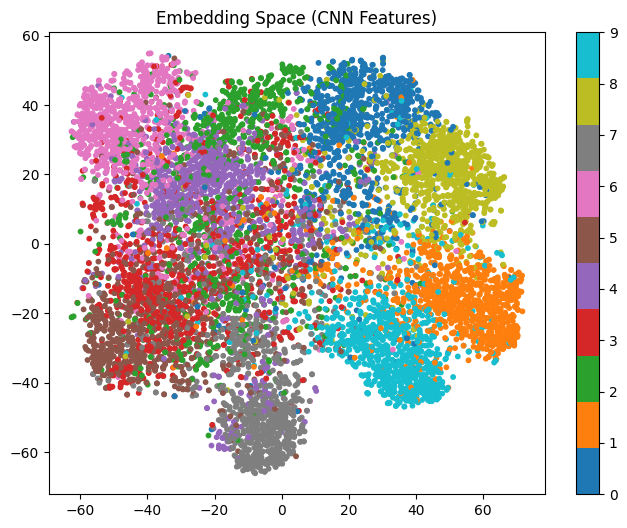

In [8]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    reduced_tsne[:,0],
    reduced_tsne[:,1],
    c=labels_list,
    cmap='tab10',
    s=10
)

plt.colorbar(scatter)
plt.title("Embedding Space (CNN Features)")
plt.show()

In [9]:
reducer = umap.UMAP(n_components=3)
reduced = reducer.fit_transform(embeddings)

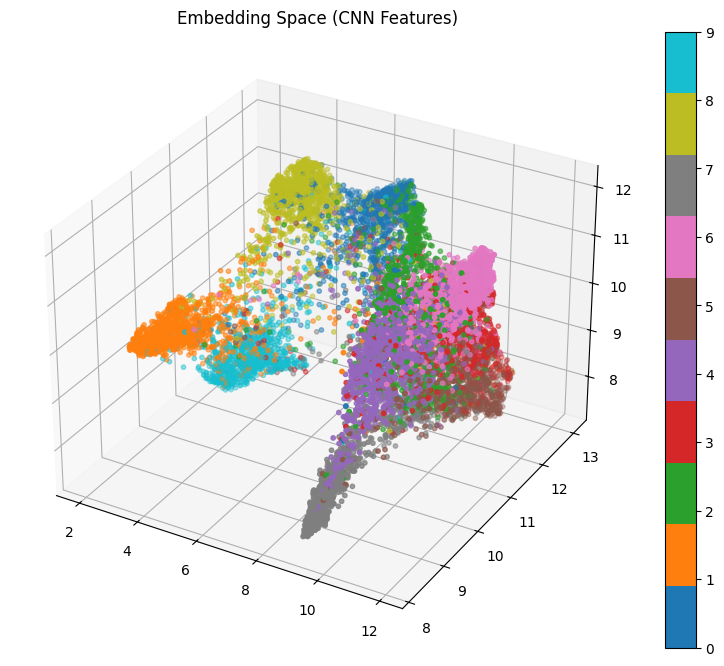

In [10]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    reduced[:, 0],
    reduced[:, 1],
    reduced[:, 2],
    c=labels_list,
    cmap='tab10',
    s=10
)

plt.colorbar(scatter)
plt.title("Embedding Space (CNN Features)")
plt.show()